# 🌌 Tutorial Interativo: Entendendo o AdaptiveV2-IS

Este notebook guia você pelo funcionamento do **AdaptiveV2-IS**, uma versão aprimorada do Adaptive-IS que usa estimação por **densidade de quartil** em vez de GMM 1D.

### O que você vai ver:
1. **Configuração do Dataset** — escolha de dataset e scorer base.
2. **Scoring (Passo 1)** — pontuação de instâncias pelo scorer base.
3. **Estimação de parâmetros por quartil (Passo 2)** — beta_q1, beta_q2, theta calculados a partir de largura de quartis.
4. **Aplicação da seleção (Passo 3)** — corte por zonas Q1, Q2, Q3, Q4.
5. **Métricas por classe** — quantas instâncias foram mantidas/removidas por classe.

---

## 🛠️ Passo 0: Configuração

Escolha:
- `DATASET_NAME`: `'synthetic'`, `'webkb'`, `'twitter'`, etc.
- `BASE_METHOD`: `'gmm'`, `'autoencoder'` ou `'perplexity'`.

In [12]:
%load_ext autoreload
%autoreload 2

import os, sys, torch
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
sys.path.append('..')

print(torch.cuda.device_count())   # 1
print(torch.cuda.get_device_name(0))  # continua A100

# ========== CONFIGURAÇÃO ==========
DATASET_NAME = 'ohsumed'   # 'synthetic', 'webkb', 'twitter', etc.
BASE_METHOD  = 'autoencoder'  # 'gmm', 'autoencoder', 'perplexity'
RANDOM_STATE = 0
# ==================================

print('Dataset :', DATASET_NAME.upper())
print('Scorer  :', BASE_METHOD.upper())

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
1
NVIDIA A100-SXM4-80GB
Dataset : OHSUMED
Scorer  : AUTOENCODER


### Carregando o Dataset

- `'synthetic'` — 2D, desbalanceado (85/15%), útil para visualização.
- Datasets reais — carregados a partir de `/data/bernardolemos/datasets/<nome>/tfidf/`.

In [13]:
import numpy as np
from src.main.python.utils.general import get_data

if DATASET_NAME == 'synthetic':
    from sklearn.datasets import make_classification
    X_train, y_train = make_classification(
        n_samples=1200, n_features=2, n_informative=2,
        n_redundant=0, n_clusters_per_class=1,
        weights=[0.85, 0.15], class_sep=1.5,
        flip_y=0.01, random_state=RANDOM_STATE
    )
    np.random.seed(RANDOM_STATE)
    outlier_idx = np.random.choice(len(X_train), size=30, replace=False)
    X_train[outlier_idx] += np.random.uniform(-7, 7, size=(30, 2))
    X_test, y_test = X_train.copy(), y_train.copy()
    print(f'Sintético: {X_train.shape[0]} amostras, {X_train.shape[1]} dims')
    print(f'Classes  : {np.bincount(y_train)}')
else:
    inputdir = f'..//data/bernardolemos/datasets/{DATASET_NAME}/jina-v5/'
    X_train, y_train, X_test, y_test, n_classes = get_data(inputdir, f=0)
    print(f"Dataset real '{DATASET_NAME}' carregado:")
    print(f'  X_train: {X_train.shape}')
    print(f'  Classes: {np.bincount(y_train)}')

Dataset real 'ohsumed' carregado:
  X_train: (16471, 256)
  Classes: [ 568  224  165 2262  454  753  119  570  152 1195  303  758  426 2588
  276  321  533  734  180  954 1155   50 1731]


## 📈 Passo 1: Scoring com AdaptiveV2-IS

O `AdaptiveV2IS` usa o mesmo scorer base que o `AdaptiveIS`, mas a estimação de parâmetros é **puramente não-paramétrica** — sem GMM.

- **GMM-IS**: scores = log-likelihood negativo.
- **Autoencoder-IS**: scores = erro de reconstrução MSE.
- **Perplexity-IS**: scores = perplexidade LDA.

In [14]:
from src.main.python.iSel.adaptive_v2_is import AdaptiveV2IS

selector_v2 = AdaptiveV2IS(
    base_method=BASE_METHOD,
    random_state=RANDOM_STATE
)

X_sel, y_sel = selector_v2.select_data(X_train, y_train)
scores = selector_v2.scores_

print(f'\nScores ({BASE_METHOD.upper()}):')
print(f'  min={scores.min():.4f}  p25={np.percentile(scores,25):.4f}')
print(f'  median={np.median(scores):.4f}  p75={np.percentile(scores,75):.4f}')
print(f'  max={scores.max():.4f}')

[AdaptiveV2-IS] Step 1 — scoring via 'autoencoder' …
[AE-IS] Using GPU: NVIDIA A100-SXM4-80GB
[AE-IS] Architecture: 256 → 160 → 64 → 160 → 256
[AE-IS] Training autoencoder on 16471 instances (256 features) for up to 50 epochs …
  Epoch   1/50 — loss: 0.758675 (best: 0.758675)
  Epoch  10/50 — loss: 0.230345 (best: 0.230345)
  Epoch  20/50 — loss: 0.198258 (best: 0.198258)
  Epoch  30/50 — loss: 0.185266 (best: 0.185266)
  Epoch  40/50 — loss: 0.178628 (best: 0.178628)
  Epoch  50/50 — loss: 0.174728 (best: 0.174728)
[AE-IS] Training finished — best loss: 0.174728
[AE-IS] Reconstruction error stats — min: 0.021633, median: 0.096025, max: 1.396419
[AE-IS] Removed 0 redundant + 0 noisy = 0 total instances
[AE-IS] Kept 16471 / 16471 (reduction = 0.00%)
[AdaptiveV2-IS] Score stats — min: 0.0216, p25: 0.0735, median: 0.0960, p75: 0.1295, max: 1.3964
[AdaptiveV2-IS] Step 2 — estimating params via quartile density …
[AdaptiveV2-IS] Quartile widths: Q1_frac=0.038, Q2_frac=0.016, total_range=1.3

### Plot 1: Histograma de Scores com Zonas de Quartil

O AdaptiveV2-IS divide os scores em 4 zonas:
- **Q1** (≤ P25): zona de alta redundância → remoção agressiva com `beta_q1`.
- **Q2** (P25–P50): zona de redundância secundária → remoção moderada com `beta_q2`.
- **Q3** (P50–P75): zona informativa → **preservada integralmente**.
- **Q4** (> P75): zona de ruído potencial → remoção suave com `theta`, modulada pelo imbalance proxy.

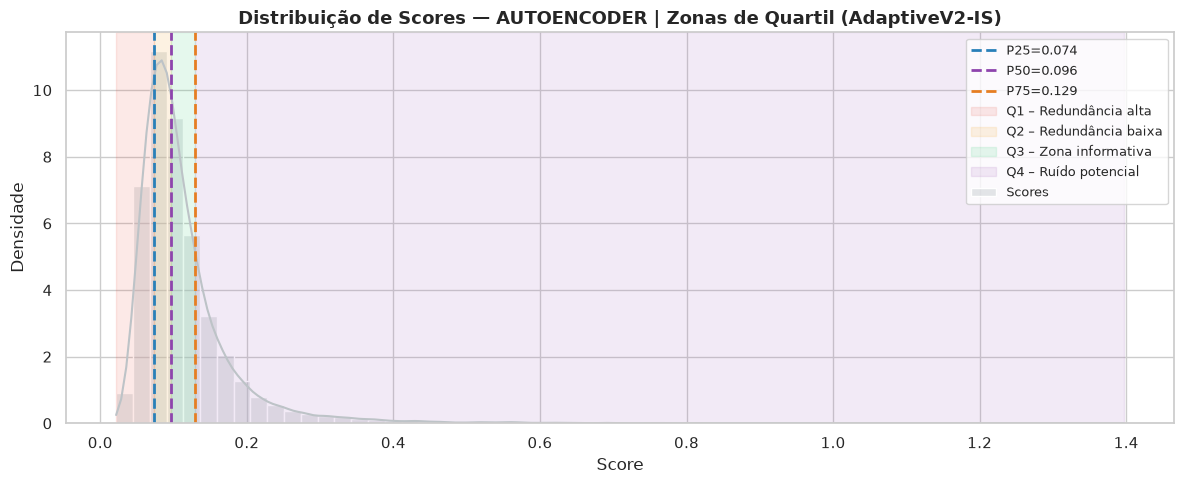

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

p25, p50, p75 = selector_v2.p25_, selector_v2.p50_, selector_v2.p75_

fig, ax = plt.subplots(figsize=(12, 5))
sns.set_theme(style='whitegrid')
sns.histplot(scores, kde=True, color='#bdc3c7', stat='density',
             bins=60, alpha=0.4, label='Scores', ax=ax)

# Quartile lines
ax.axvline(p25, color='#2980b9', linestyle='--', lw=2, label=f'P25={p25:.3f}')
ax.axvline(p50, color='#8e44ad', linestyle='--', lw=2, label=f'P50={p50:.3f}')
ax.axvline(p75, color='#e67e22', linestyle='--', lw=2, label=f'P75={p75:.3f}')

# Zone fills
smin, smax = scores.min(), scores.max()
ax.axvspan(smin,  p25, color='#e74c3c', alpha=0.12, label='Q1 – Redundância alta')
ax.axvspan(p25,  p50, color='#f39c12', alpha=0.12, label='Q2 – Redundância baixa')
ax.axvspan(p50,  p75, color='#2ecc71', alpha=0.12, label='Q3 – Zona informativa')
ax.axvspan(p75, smax, color='#9b59b6', alpha=0.12, label='Q4 – Ruído potencial')

ax.set_title(f'Distribuição de Scores — {BASE_METHOD.upper()} | Zonas de Quartil (AdaptiveV2-IS)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Score')
ax.set_ylabel('Densidade')
ax.legend(fontsize=9, loc='upper right')
plt.tight_layout()
plt.show()

## 🔢 Passo 2: Parâmetros Estimados por Densidade de Quartil

A lógica central: cada quartil contém **25% dos dados**; logo a **largura** do quartil é inversamente proporcional à densidade local.

$$\\text{frac}_{Q_i} = \\frac{\\text{width}_{Q_i}}{\\text{total\_range}}$$

$$\\beta_{Q_i} = \\text{clip}(1 - \\text{frac}_{Q_i},\ \\text{lo},\ \\text{hi})$$

- Quartil **estreito** → alta densidade → remoção agressiva.
- Quartil **largo** → baixa densidade → remoção conservadora.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Parâmetros AdaptiveV2-IS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  P25 (fronteira Q1→Q2)   : 0.0735
  P50 (fronteira Q2→Q3)   : 0.0960
  P75 (fronteira Q3→Q4)   : 0.1295
  beta_q1 (remoção Q1)    : 0.500
  beta_q2 (remoção Q2)    : 0.400
  theta   (remoção Q4)    : 0.166
  imbalance_proxy         : 0.793
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


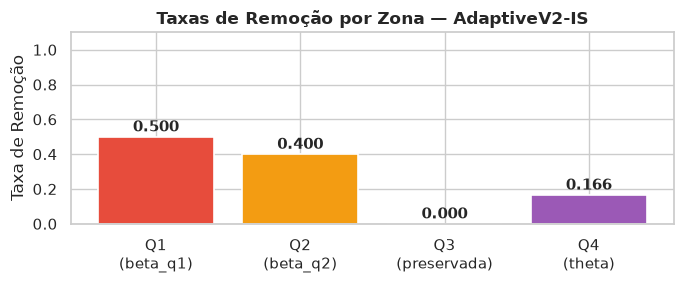

In [16]:
params = dict(
    beta_q1  = selector_v2.beta_q1_,
    beta_q2  = selector_v2.beta_q2_,
    theta    = selector_v2.theta_,
    imbalance_proxy = selector_v2.imbalance_proxy_,
)

print('━'*50)
print('  Parâmetros AdaptiveV2-IS')
print('━'*50)
print(f"  P25 (fronteira Q1→Q2)   : {selector_v2.p25_:.4f}")
print(f"  P50 (fronteira Q2→Q3)   : {selector_v2.p50_:.4f}")
print(f"  P75 (fronteira Q3→Q4)   : {selector_v2.p75_:.4f}")
print(f"  beta_q1 (remoção Q1)    : {params['beta_q1']:.3f}")
print(f"  beta_q2 (remoção Q2)    : {params['beta_q2']:.3f}")
print(f"  theta   (remoção Q4)    : {params['theta']:.3f}")
print(f"  imbalance_proxy         : {params['imbalance_proxy']:.3f}")
print('━'*50)

# Visual bar chart of removal rates
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(7, 3))
zones   = ['Q1\n(beta_q1)', 'Q2\n(beta_q2)', 'Q3\n(preservada)', 'Q4\n(theta)']
rates   = [params['beta_q1'], params['beta_q2'], 0.0, params['theta']]
colors  = ['#e74c3c', '#f39c12', '#2ecc71', '#9b59b6']
bars    = ax.bar(zones, rates, color=colors, edgecolor='white', linewidth=1.2)
for bar, rate in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{rate:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Taxa de Remoção')
ax.set_title('Taxas de Remoção por Zona — AdaptiveV2-IS', fontweight='bold')
plt.tight_layout()
plt.show()

## ✂️ Passo 3: Resultado da Seleção

Resumo global da seleção aplicada pelo AdaptiveV2-IS.

In [17]:
n_total   = len(y_train)
n_kept    = len(y_sel)
n_removed = n_total - n_kept
reduction = 1.0 - n_kept / n_total

print('━'*50)
print('  Resultado da Seleção (AdaptiveV2-IS)')
print('━'*50)
print(f'  Total original : {n_total:>6}')
print(f'  Mantidas       : {n_kept:>6}  ({100*(1-reduction):.1f}%)')
print(f'  Removidas      : {n_removed:>6}  ({100*reduction:.1f}%)')
print('━'*50)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Resultado da Seleção (AdaptiveV2-IS)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Total original :  16471
  Mantidas       :  12083  (73.4%)
  Removidas      :   4388  (26.6%)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


## 📊 Passo 4: Métricas por Classe

Uma das vantagens do AdaptiveV2-IS é a **modulação pelo Imbalance Proxy**, que protege classes minoritárias.
Aqui analisamos, para cada classe, quantas instâncias foram **mantidas** e **removidas**.

Number of classes where original percentage is less than after: 16
Number of classes where original percentage is greater than after: 7
 Classe  Total  Mantidas  Removidas  Pct_Classe_Original  Pct_Classe_Apos  Pct_Mantidas  Pct_Removidas
      0    568       468        100                 3.45             3.87          82.4           17.6
      1    224       177         47                 1.36             1.46          79.0           21.0
      2    165       141         24                 1.00             1.17          85.5           14.5
      3   2262      1524        738                13.73            12.61          67.4           32.6
      4    454       369         85                 2.76             3.05          81.3           18.7
      5    753       540        213                 4.57             4.47          71.7           28.3
      6    119        93         26                 0.72             0.77          78.2           21.8
      7    570       431        139     

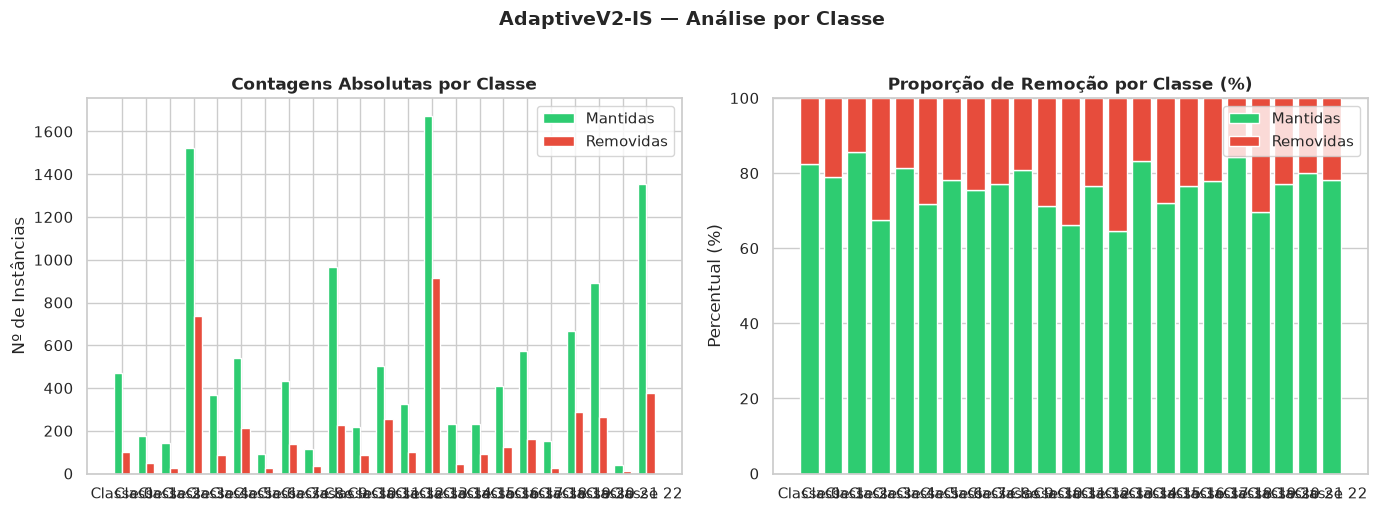

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

mask = selector_v2.mask  # True = mantida
classes = np.unique(y_train)
n_total = len(y_train)
n_kept = int(mask.sum())

rows = []
for c in classes:
    idx_c      = y_train == c
    total_c    = int(idx_c.sum())
    kept_c     = int((mask & idx_c).sum())
    removed_c  = total_c - kept_c
    pct_class_before = 100 * total_c / n_total
    pct_class_after  = (100 * kept_c / n_kept) if n_kept > 0 else 0.0
    pct_kept   = 100 * kept_c   / total_c
    pct_removed= 100 * removed_c/ total_c
    rows.append(dict(
        Classe=c,
        Total=total_c,
        Mantidas=kept_c,
        Removidas=removed_c,
        Pct_Classe_Original=round(pct_class_before, 2),
        Pct_Classe_Apos=round(pct_class_after, 2),
        Pct_Mantidas=round(pct_kept, 1),
        Pct_Removidas=round(pct_removed, 1),
    ))

df = pd.DataFrame(rows)
print(f"Number of classes where original percentage is less than after: {df[df['Pct_Classe_Original'] < df['Pct_Classe_Apos']].shape[0]}")
print(f"Number of classes where original percentage is greater than after: {df[df['Pct_Classe_Original'] > df['Pct_Classe_Apos']].shape[0]}")
print(df.to_string(index=False))

# ── Gráfico de barras empilhadas ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Esquerda: contagens absolutas
ax = axes[0]
x  = np.arange(len(classes))
w  = 0.35
ax.bar(x - w/2, df['Mantidas'],  w, label='Mantidas',  color='#2ecc71', edgecolor='white')
ax.bar(x + w/2, df['Removidas'], w, label='Removidas', color='#e74c3c', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels([f'Classe {c}' for c in classes])
ax.set_ylabel('Nº de Instâncias')
ax.set_title('Contagens Absolutas por Classe', fontweight='bold')
ax.legend()

# Direita: proporções percentuais (barras empilhadas 100%)
ax = axes[1]
ax.bar(x, df['Pct_Mantidas'],  label='Mantidas',  color='#2ecc71', edgecolor='white')
ax.bar(x, df['Pct_Removidas'], bottom=df['Pct_Mantidas'],
       label='Removidas', color='#e74c3c', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels([f'Classe {c}' for c in classes])
ax.set_ylim(0, 100)
ax.set_ylabel('Percentual (%)')
ax.set_title('Proporção de Remoção por Classe (%)', fontweight='bold')
ax.legend()

plt.suptitle('AdaptiveV2-IS — Análise por Classe', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 🔬 Passo 4.5: Análise dos Erros de Reconstrução por Classe

Esta célula estuda **como os erros de reconstrução do autoencoder se distribuem por classe**.

- Classes com **erros médios baixos** → o autoencoder as representa facilmente (provavelmente majoritárias ou muito homogêneas).
- Classes com **erros médios altos** → o autoencoder tem dificuldade (podem ser minoritárias ou atípicas).

Comparar a **frequência da classe** com o **erro médio de reconstrução** revela se há correlação entre raridade e dificuldade de representação — premissa que o método adaptativo pode explorar de forma mais informada.


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ── Coleta de estatísticas de erro por classe ──────────────────────────────
# scores_ contém o erro de reconstrução MSE por instância (calculado no Passo 1)
scores = selector_v2.scores_
classes = np.unique(y_train)
n_total = len(y_train)

rows_err = []
for c in classes:
    idx_c = y_train == c
    erros_c = scores[idx_c]
    rows_err.append(dict(
        Classe=int(c),
        N=int(idx_c.sum()),
        Freq_pct=round(100 * idx_c.sum() / n_total, 3),
        Erro_medio=round(float(erros_c.mean()), 5),
        Erro_mediana=round(float(np.median(erros_c)), 5),
        Erro_std=round(float(erros_c.std()), 5),
        Erro_min=round(float(erros_c.min()), 5),
        Erro_max=round(float(erros_c.max()), 5),
    ))

df_err = pd.DataFrame(rows_err).sort_values('N', ascending=False)

print('━'*85)
print('  Erros de Reconstrução por Classe (ordenado por frequência, maior → menor)')
print('━'*85)
print(df_err.to_string(index=False))
print('━'*85)

# ── Correlação global ──────────────────────────────────────────────────────


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Erros de Reconstrução por Classe (ordenado por frequência, maior → menor)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 Classe    N  Freq_pct  Erro_medio  Erro_mediana  Erro_std  Erro_min  Erro_max
     13 2588    15.712     0.08467       0.07111   0.05277   0.02163   0.94526
      3 2262    13.733     0.09692       0.08303   0.05549   0.03460   0.95751
     22 1731    10.509     0.12808       0.10461   0.08441   0.03545   0.91076
      9 1195     7.255     0.13466       0.11504   0.07378   0.04834   0.77310
     20 1155     7.012     0.16547       0.12823   0.11266   0.04217   1.39642
     19  954     5.792     0.10867       0.09452   0.05981   0.03547   0.58848
     11  758     4.602     0.09329       0.08198   0.04826   0.03750   0.46569
      5  753     4.572     0.10693       0.09399   0.05138   0.03974   0.52704
     17  734     4.456     0.12260       

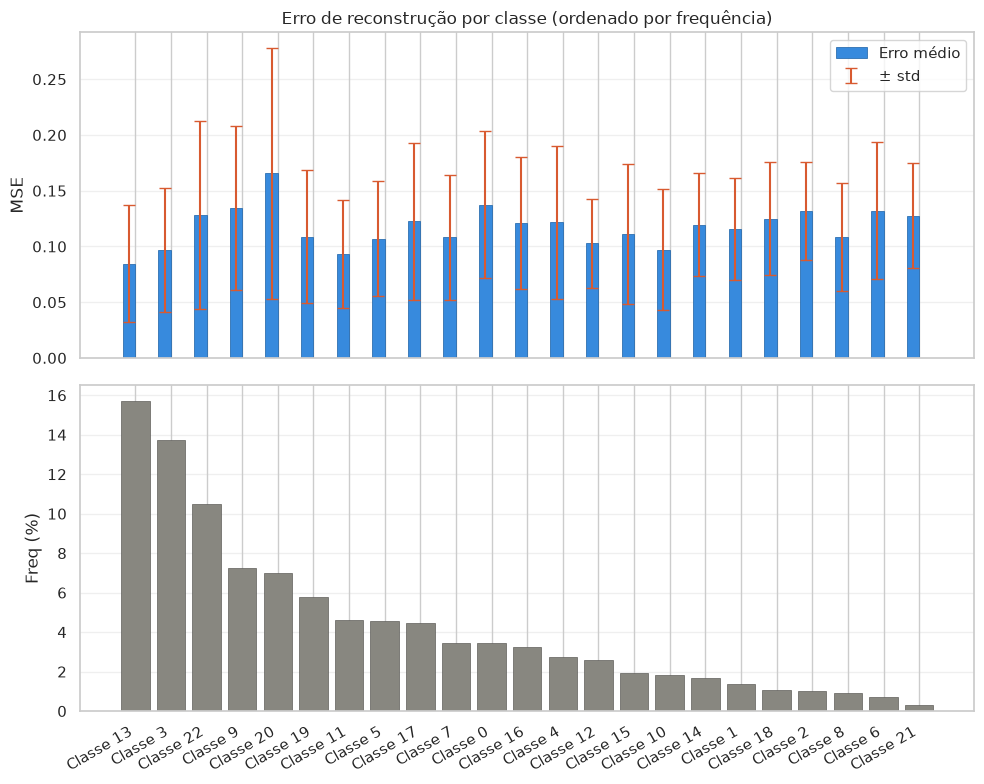

In [20]:
# ── Plot: erro de reconstrução por classe ──────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

classes_sorted = df_err['Classe'].tolist()
x = np.arange(len(classes_sorted))
width = 0.35

# Barras: erro médio e mediana
bars1 = ax1.bar(x - width/2, df_err['Erro_medio'], width, label='Erro médio',
                color='#378ADD', edgecolor='#185FA5', linewidth=0.5)
# bars2 = ax1.bar(x + width/2, df_err['Erro_mediana'], width, label='Erro mediana',
#                 color='#1D9E75', edgecolor='#0F6E56', linewidth=0.5)

# Barras de erro ± std sobre o erro médio
ax1.errorbar(x - width/2, df_err['Erro_medio'], yerr=df_err['Erro_std'],
             fmt='none', color='#D85A30', capsize=4, linewidth=1.5, label='± std')

ax1.set_ylabel('MSE')
ax1.set_title('Erro de reconstrução por classe (ordenado por frequência)')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Barras: frequência
ax2.bar(x, df_err['Freq_pct'], color='#888780', edgecolor='#5F5E5A', linewidth=0.5)
ax2.set_ylabel('Freq (%)')
ax2.set_xticks(x)
ax2.set_xticklabels([f'Classe {c}' for c in classes_sorted], rotation=30, ha='right')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 🗺️ Passo 5: Visualização Espacial (2D)

Projeção das instâncias em 2D (SVD truncado) colorida por decisão do AdaptiveV2-IS.

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import scipy.sparse as sp

X_dense = X_train.toarray() if sp.issparse(X_train) else X_train

if X_dense.shape[1] > 2:
    tsne = TSNE(
        n_components=2,
        random_state=RANDOM_STATE,
        perplexity=30,     # tune depending on dataset size
        learning_rate='auto',
        init='pca'
    )
    X2d = tsne.fit_transform(X_dense)
else:
    X2d = X_dense

kept = mask.astype(bool)
removed = ~kept

fig, ax = plt.subplots(figsize=(9, 6))

# Color by true class, while keeping kept/removed markers distinct
# ax.scatter(
#     X2d[kept, 0], X2d[kept, 1],
#     s=15, alpha=0.65,
#     c=y_train[kept],
#     cmap='tab10',
#     marker='o',
#     label=f'Mantidas ({kept.sum()})'
# )

ax.scatter(
    X2d[removed, 0], X2d[removed, 1],
    s=25, alpha=0.8,
    c=y_train[removed],
    cmap='tab10',
    marker='x',
    linewidths=1.2,
    label=f'Removidas ({removed.sum()})'
)

ax.set_title(
    't-SNE 2D — Instâncias Mantidas vs. Removidas (AdaptiveV2-IS)\nCor = Classe Real',
    fontweight='bold'
)
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.legend()

plt.tight_layout()
plt.show()

## 🎓 Conclusão

O **AdaptiveV2-IS** oferece uma abordagem mais robusta que o AdaptiveIS original:

| Característica | AdaptiveIS | AdaptiveV2-IS |
|---|---|---|
| Estimação de thresholds | GMM 1D (paramétrico) | Densidade de quartil (não-paramétrico) |
| Falha em spikes | Sim (GMM colapsa) | Não |
| Zonas de remoção | Baixo + Alto | Q1 + Q2 + Q4 |
| Zona preservada | Médio | Q3 (P50–P75) |
| Proteção de minoria | Via imbalance proxy | Via imbalance proxy (theta modulado) |

As métricas por classe mostram se as classes minoritárias estão sendo protegidas adequadamente.